In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\data sheets\\tendulkar_ODI.csv')

# Preview
print(df.shape)
df.head()


(295, 13)


,Unnamed: 0,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date
0,1,0,-,2,0,0,0,5,caught,2,v Pakistan,Gujranwala,18-Dec-89
1,2,0,2,2,0,0,0,5,caught,2,v New Zealand,Dunedin,1-Mar-90
2,3,36,51,39,5,0,92.3,6,caught,1,v New Zealand,Wellington,6-Mar-90
3,4,19,38,35,1,1,54.28,4,bowled,2,v England,Leeds,18-Jul-90
4,5,31,31,26,3,0,119.23,6,bowled,2,v England,Nottingham,20-Jul-90


In [71]:
import numpy as np

def clean_runs(x):
    """
    Cleans the 'Runs' column from cricket scorecards.
    
    Parameters:
    x (str or int): Raw value from the 'Runs' column.
    
    Returns:
    int or np.nan: Cleaned numeric score or NaN if invalid.
    """
    # Handle missing or non-batting entries
    if x in ['DNB', '-', 'TDNB', 'absent', 'retired hurt']:
        return np.nan
    
    # Handle not-out scores (e.g., '45*')
    if isinstance(x, str) and x.endswith('*'):
        try:
            return int(x.rstrip('*'))
        except ValueError:
            return np.nan
    
    # Handle regular numeric entries
    try:
        return int(x)
    except (ValueError, TypeError):
        return np.nan


In [72]:
df['Runs'] = df['Runs'].apply(clean_runs)

In [73]:
# Clean '4s' column (replace '-' with 0)
df['4s'] = df['4s'].replace('-', 0).astype(int)

In [74]:
# Quick check
df[['Runs','4s']].head(15)

,Runs,4s
0,0.0,0
1,0.0,0
2,36.0,5
3,19.0,1
4,31.0,3
5,36.0,3
6,53.0,7
7,30.0,1
8,NaN,0
9,4.0,0


count    292.000000
mean      39.448630
std       39.933374
min        0.000000
25%        7.000000
50%       27.500000
75%       62.250000
max      200.000000
Name: Runs, dtype: float64


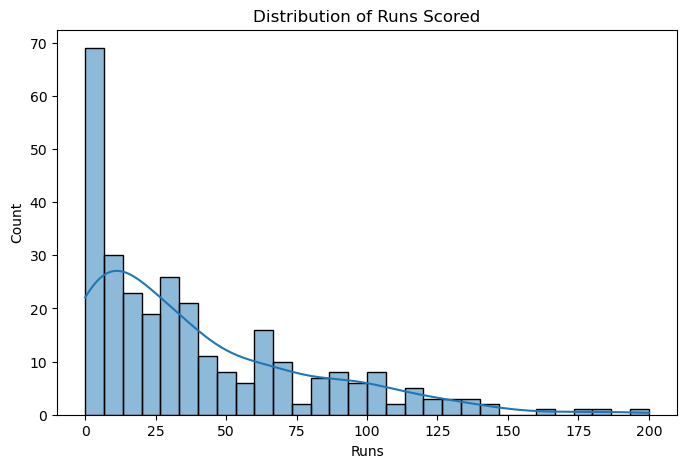

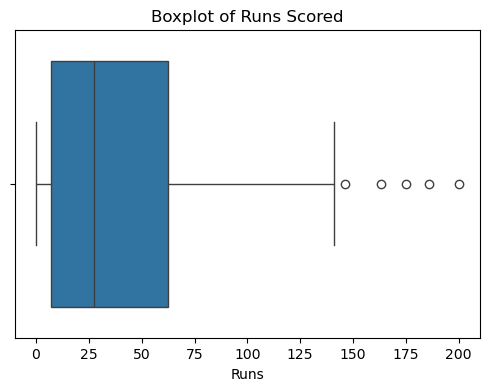

In [75]:
#Univariate Analysis (Runs)
print(df['Runs'].describe())

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Runs'].dropna(), bins=30, kde=True)
plt.title("Distribution of Runs Scored")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Runs'])
plt.title("Boxplot of Runs Scored")
plt.show()


count    295.000000
mean       4.461017
std        4.727723
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       25.000000
Name: 4s, dtype: float64


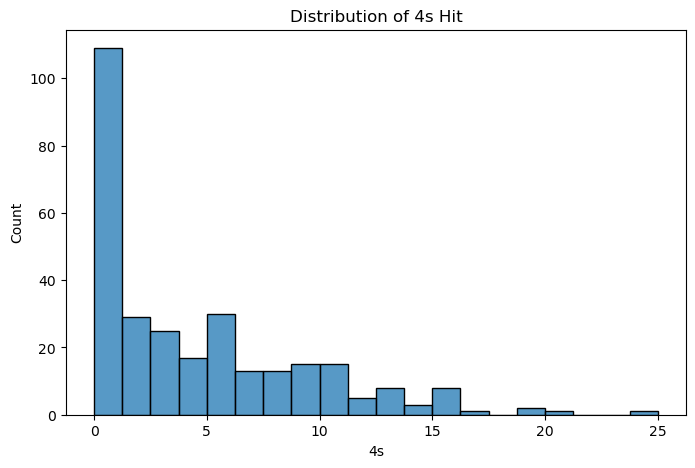

In [76]:
#Univariate Analysis (4s)
print(df['4s'].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['4s'], bins=20, kde=False)
plt.title("Distribution of 4s Hit")
plt.show()


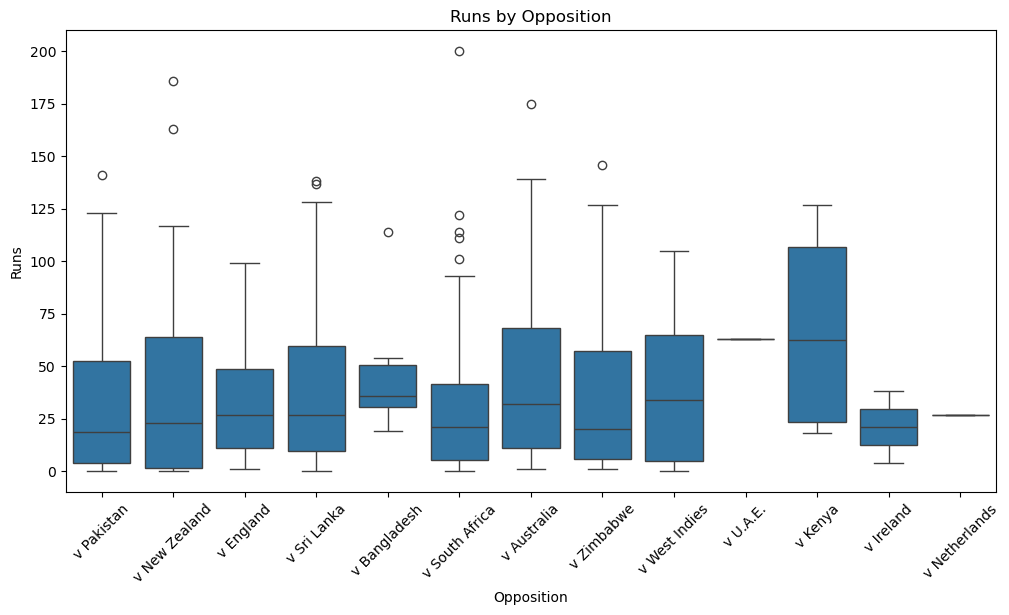

In [77]:
#Segmented Univariate Analysis
plt.figure(figsize=(12,6))
sns.boxplot(x='Opposition', y='Runs', data=df)
plt.title("Runs by Opposition")
plt.xticks(rotation=45)
plt.show()


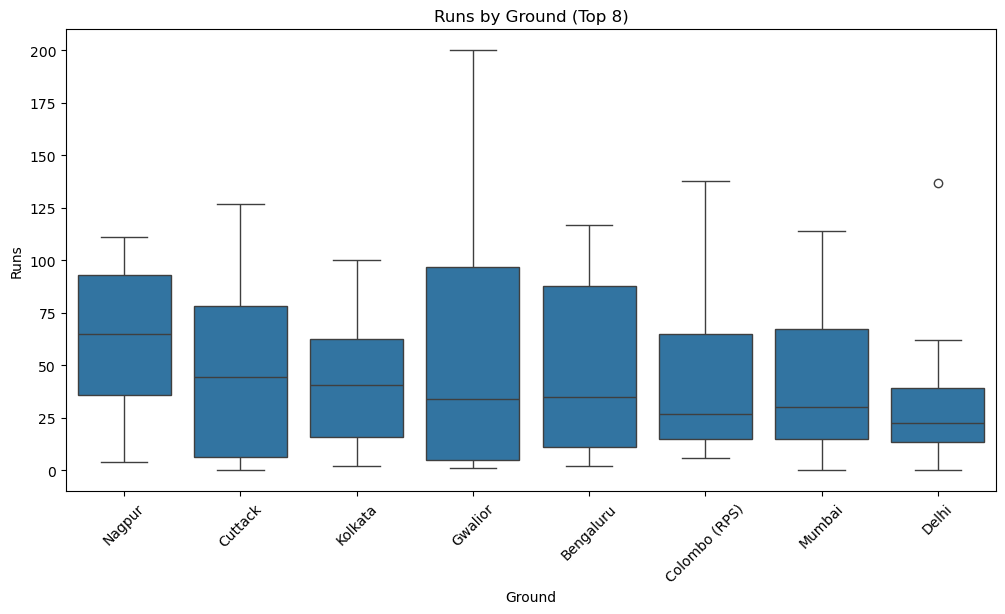

In [78]:
#Runs by Ground
top_grounds = df['Ground'].value_counts().head(8).index
plt.figure(figsize=(12,6))
sns.boxplot(x='Ground', y='Runs', data=df[df['Ground'].isin(top_grounds)])
plt.title("Runs by Ground (Top 8)")
plt.xticks(rotation=45)
plt.show()


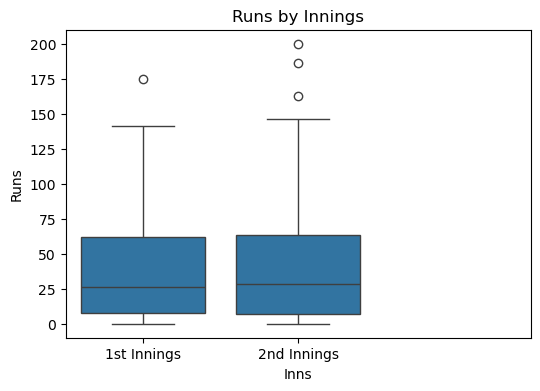

In [79]:
# Runs by Innings (1st vs 2nd Innings)
plt.figure(figsize=(6,4))
sns.boxplot(x='Inns', y='Runs', data=df)
plt.title("Runs by Innings")
plt.xticks([0,1], ['1st Innings','2nd Innings'])
plt.show()


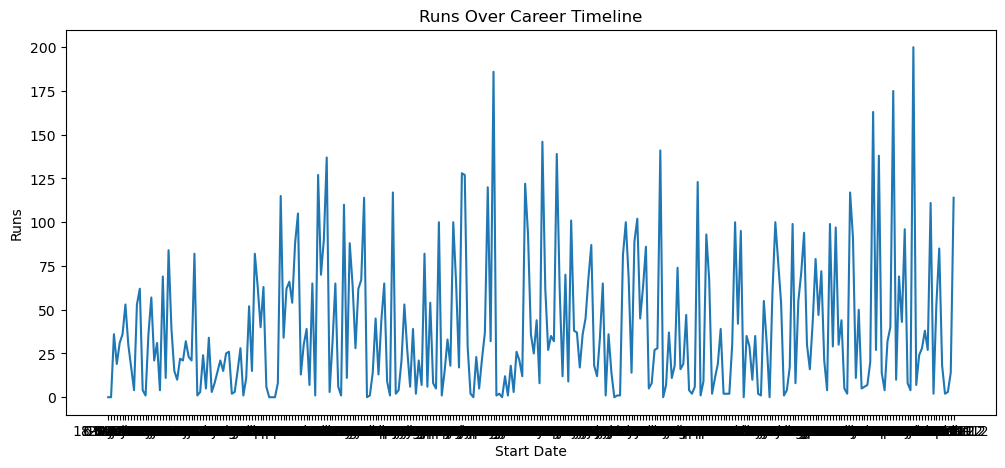

In [80]:
#Runs over Career Timeline
plt.figure(figsize=(12,5))
sns.lineplot(x='Start Date', y='Runs', data=df)
plt.title("Runs Over Career Timeline")
plt.show()


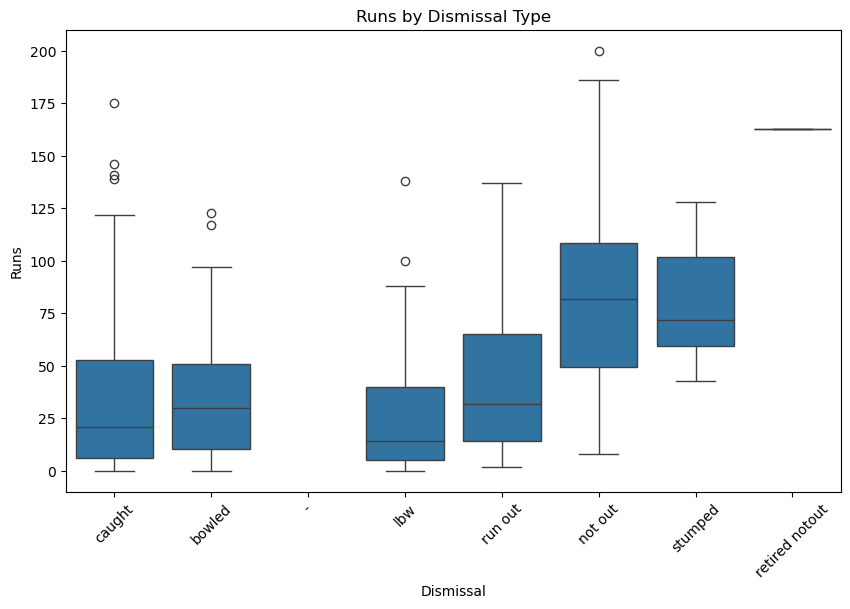

In [81]:
# Segmented by Dismissal Type
plt.figure(figsize=(10,6))
sns.boxplot(x='Dismissal', y='Runs', data=df)
plt.title("Runs by Dismissal Type")
plt.xticks(rotation=45)
plt.show()
